In [44]:
import os
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score

In [52]:
raw_path = "../data/raw/"

In [46]:
df = pd.read_csv(os.path.join(raw_path, "clean2.data"), header=None)
n_cols = df.shape[1]
columns = ["ID"] + [f"attr_{i}" for i in range(1, n_cols)]
df.columns = columns

In [47]:
df.head()

,ID,attr_1,attr_2,attr_3,attr_4,attr_5,attr_6,attr_7,attr_8,attr_9,...,attr_159,attr_160,attr_161,attr_162,attr_163,attr_164,attr_165,attr_166,attr_167,attr_168
0,MUSK-211,211_1+1,46,-108,-60,-69,-117,49,38,-161,...,-308,52,-7,39,126,156,-50,-112,96,1.0
1,MUSK-211,211_1+10,41,-188,-145,22,-117,-6,57,-171,...,-59,-2,52,103,136,169,-61,-136,79,1.0
2,MUSK-211,211_1+11,46,-194,-145,28,-117,73,57,-168,...,-134,-154,57,143,142,165,-67,-145,39,1.0
3,MUSK-211,211_1+12,41,-188,-145,22,-117,-7,57,-170,...,-60,-4,52,104,136,168,-60,-135,80,1.0
4,MUSK-211,211_1+13,41,-188,-145,22,-117,-7,57,-170,...,-60,-4,52,104,137,168,-60,-135,80,1.0


In [48]:
numeric_df = df.select_dtypes(include=np.number)

X_numeric = numeric_df.values

In [49]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_numeric)

In [50]:
df['target'] = df['ID'].apply(lambda x: 1 if x.startswith('MUSK') else 0)

In [51]:
X = X_scaled
y = df['target'].values

print("Numerički podaci skalirani i spremni za modele")
print("X shape:", X.shape)
print("y shape:", y.shape)

Numerički podaci skalirani i spremni za modele
X shape: (6598, 167)
y shape: (6598,)


##SVM##

In [42]:
# --- PCA20 ---
pca20 = PCA(n_components=20)
X_pca20 = pca20.fit_transform(X_scaled)

# --- PCA40 ---
pca40 = PCA(n_components=40)
X_pca40 = pca40.fit_transform(X_scaled)

In [53]:
models_path = "../notebooks/models"

In [54]:
svm_raw = joblib.load(f"{models_path}/svm_raw_final.joblib")
svm_pca20 = joblib.load(f"{models_path}/svm_pca20_final.joblib")
svm_pca40 = joblib.load(f"{models_path}/svm_pca40_final.joblib")

In [55]:
y_pred_raw = svm_raw.predict(X)
y_pred_pca20 = svm_pca20.predict(X_pca20)
y_pred_pca40 = svm_pca40.predict(X_pca40)

C:\Users\Korisnik\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


In [56]:
acc_raw = accuracy_score(y, y_pred_raw)
acc_pca20 = accuracy_score(y, y_pred_pca20)
acc_pca40 = accuracy_score(y, y_pred_pca40)

print(f"SVM Raw Accuracy: {acc_raw:.4f}")
print(f"SVM PCA20 Accuracy: {acc_pca20:.4f}")
print(f"SVM PCA40 Accuracy: {acc_pca40:.4f}")

SVM Raw Accuracy: 1.0000
SVM PCA20 Accuracy: 0.9938
SVM PCA40 Accuracy: 1.0000


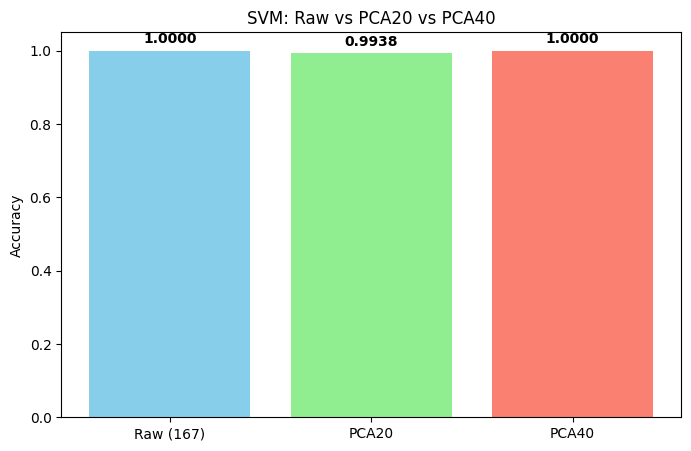

In [57]:
accuracies = [acc_raw, acc_pca20, acc_pca40]
labels = ["Raw (167)", "PCA20", "PCA40"]

plt.figure(figsize=(8,5))
plt.bar(labels, accuracies, color=['skyblue','lightgreen','salmon'])
plt.ylim(0,1.05)
plt.ylabel("Accuracy")
plt.title("SVM: Raw vs PCA20 vs PCA40")
for i, v in enumerate(accuracies):
    plt.text(i, v + 0.02, f"{v:.4f}", ha='center', fontweight='bold')
plt.show()

Uporedna tačnost SVM modela

Na slici je prikazana uporedna tačnost SVM modela treniranih na različitim skupovima podataka:

Raw podaci (svi atributi) – model postiže 100% tačnost, što ukazuje na gotovo savršenu klasifikaciju nad punim skupom numeričkih atributa.
PCA20 (20 glavnih komponenti) – model postiže 99.38% tačnost, što je i dalje izuzetno visoko, ali nešto niže od originalnog skupa, jer PCA sažima informacije u 20 komponenti i može blago izgubiti varijabilnost potrebnu za klasifikaciju.
PCA40 (40 glavnih komponenti) – model ponovo postiže 100% tačnost, što pokazuje da sa većim brojem komponenti sačuvana varijabilnost omogućava modelu da postigne istu preciznost kao na cijelom skupu podataka.

Ovi rezultati pokazuju da SVM dobro generalizuje na različite dimenzionalne redukcije, a veći broj komponenti (PCA40) omogućava performanse gotovo identične modelu treniranom na punim podacima.

##KNN##

In [58]:
knn_raw = joblib.load(os.path.join(models_path, "knn_raw_final.joblib"))
knn_pca20 = joblib.load(os.path.join(models_path, "knn_pca20_final.joblib"))

In [59]:
y_pred_raw_knn = knn_raw.predict(X)
y_pred_pca20_knn = knn_pca20.predict(X_pca20)

C:\Users\Korisnik\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


In [60]:
acc_raw_knn = accuracy_score(y, y_pred_raw_knn)
acc_pca20_knn = accuracy_score(y, y_pred_pca20_knn)

print(f"KNN Raw Accuracy: {acc_raw_knn:.4f}")
print(f"KNN PCA20 Accuracy: {acc_pca20_knn:.4f}")

KNN Raw Accuracy: 0.9930
KNN PCA20 Accuracy: 0.9882


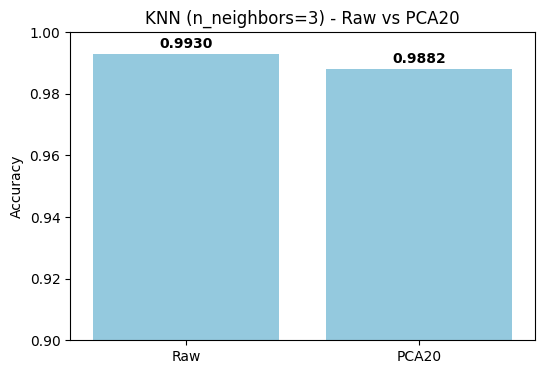

In [63]:
import seaborn as sns
plt.figure(figsize=(6,4))
sns.barplot(x=labels_knn, y=accuracy_values_knn, color="skyblue")
plt.ylim(0.9, 1.0)
plt.ylabel("Accuracy")
plt.title("KNN (n_neighbors=3) - Raw vs PCA20")
for i, v in enumerate(accuracy_values_knn):
    plt.text(i, v + 0.002, f"{v:.4f}", ha='center', fontweight='bold')
plt.show()

##LR##

In [64]:
lr_raw = joblib.load(os.path.join(models_path, "lr_raw_final.joblib"))
lr_pca20 = joblib.load(os.path.join(models_path, "lr_pca20_final.joblib"))

In [65]:
y_pred_raw_lr = lr_raw.predict(X)
y_pred_pca20_lr = lr_pca20.predict(X_pca20)

C:\Users\Korisnik\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


In [66]:
acc_raw_lr = accuracy_score(y, y_pred_raw_lr)
acc_pca20_lr = accuracy_score(y, y_pred_pca20_lr)

print(f"KNN Raw Accuracy: {acc_raw_lr:.4f}")
print(f"KNN PCA20 Accuracy: {acc_pca20_lr:.4f}")

KNN Raw Accuracy: 1.0000
KNN PCA20 Accuracy: 0.9938


C:\Users\Korisnik\AppData\Local\Temp\ipykernel_15308\2300970427.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=labels_lr, y=accuracy_values_lr, palette="Set2")


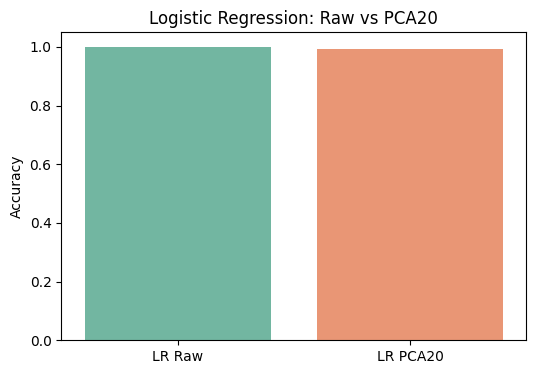

In [67]:
labels_lr = ["LR Raw", "LR PCA20"]
accuracy_values_lr = [acc_raw_lr, acc_pca20_lr]

plt.figure(figsize=(6, 4))
sns.barplot(x=labels_lr, y=accuracy_values_lr, palette="Set2")
plt.ylim(0, 1.05)  
plt.ylabel("Accuracy")
plt.title("Logistic Regression: Raw vs PCA20")
plt.show()

##RF##

In [68]:
rf_raw = joblib.load(os.path.join(models_path, "rf_raw_final.joblib"))
rf_pca20 = joblib.load(os.path.join(models_path, "random_forest_pca20_final.joblib"))

In [70]:
y_pred_raw_rf = rf_raw.predict(X)
y_pred_pca20_rf = rf_pca20.predict(X_pca20)

C:\Users\Korisnik\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [71]:
acc_raw_rf = accuracy_score(y, y_pred_raw_rf)
acc_pca20_rf = accuracy_score(y, y_pred_pca20_rf)

print(f"Random Forest Raw Accuracy: {acc_raw_rf:.4f}")
print(f"Random Forest PCA20 Accuracy: {acc_pca20_rf:.4f}")

Random Forest Raw Accuracy: 1.0000
Random Forest PCA20 Accuracy: 1.0000


C:\Users\Korisnik\AppData\Local\Temp\ipykernel_15308\618867049.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=labels_rf, y=accuracy_values_rf, palette="Set3")


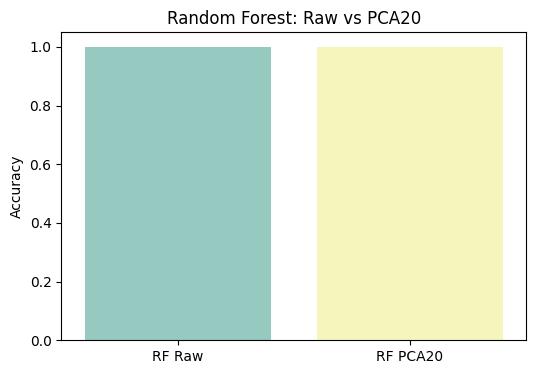

In [72]:
labels_rf = ["RF Raw", "RF PCA20"]
accuracy_values_rf = [acc_raw_rf, acc_pca20_rf]

plt.figure(figsize=(6, 4))
sns.barplot(x=labels_rf, y=accuracy_values_rf, palette="Set3")
plt.ylim(0, 1.05)
plt.ylabel("Accuracy")
plt.title("Random Forest: Raw vs PCA20")
plt.show()

##DT##

In [73]:
dt_raw = joblib.load(os.path.join(models_path, "dt_raw_final.joblib"))
dt_pca20 = joblib.load(os.path.join(models_path, "dt_pca20_final.joblib"))

In [74]:
y_pred_raw_dt = dt_raw.predict(X)
y_pred_pca20_dt = dt_pca20.predict(X_pca20)

C:\Users\Korisnik\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


In [76]:
acc_raw_dt = accuracy_score(y, y_pred_raw_dt)
acc_pca20_dt = accuracy_score(y, y_pred_pca20_dt)

print(f"Decision Tree Raw Accuracy: {acc_raw_dt:.4f}")
print(f"Decision Tree PCA20 Accuracy: {acc_pca20_dt:.4f}")

Decision Tree Raw Accuracy: 1.0000
Decision Tree PCA20 Accuracy: 0.9938


C:\Users\Korisnik\AppData\Local\Temp\ipykernel_15308\204404102.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=labels_dt, y=accuracy_values_dt, palette="Set2")


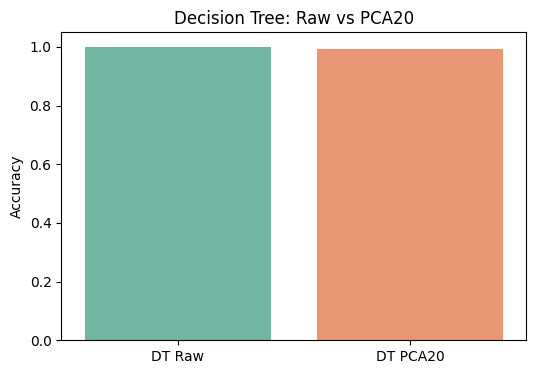

In [77]:
labels_dt = ["DT Raw", "DT PCA20"]
accuracy_values_dt = [acc_raw_dt, acc_pca20_dt]

plt.figure(figsize=(6, 4))
sns.barplot(x=labels_dt, y=accuracy_values_dt, palette="Set2")
plt.ylim(0, 1.05)
plt.ylabel("Accuracy")
plt.title("Decision Tree: Raw vs PCA20")
plt.show()